In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_csv("final_df.csv")
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label,final_group
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues,Acoustic
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues,Acoustic
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues,Acoustic
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues,Acoustic
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues,Acoustic


### Because KNN suffers from curse of dimensionality we drop variables that will lead less to interpretability, and strictly focus on music related variables. 
- We also remove variables that don't add new information (variables that are colinear or lead to multicollinearty)

In [89]:
df = df.drop(['label', 'filename', 'length','mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var'], axis=1)


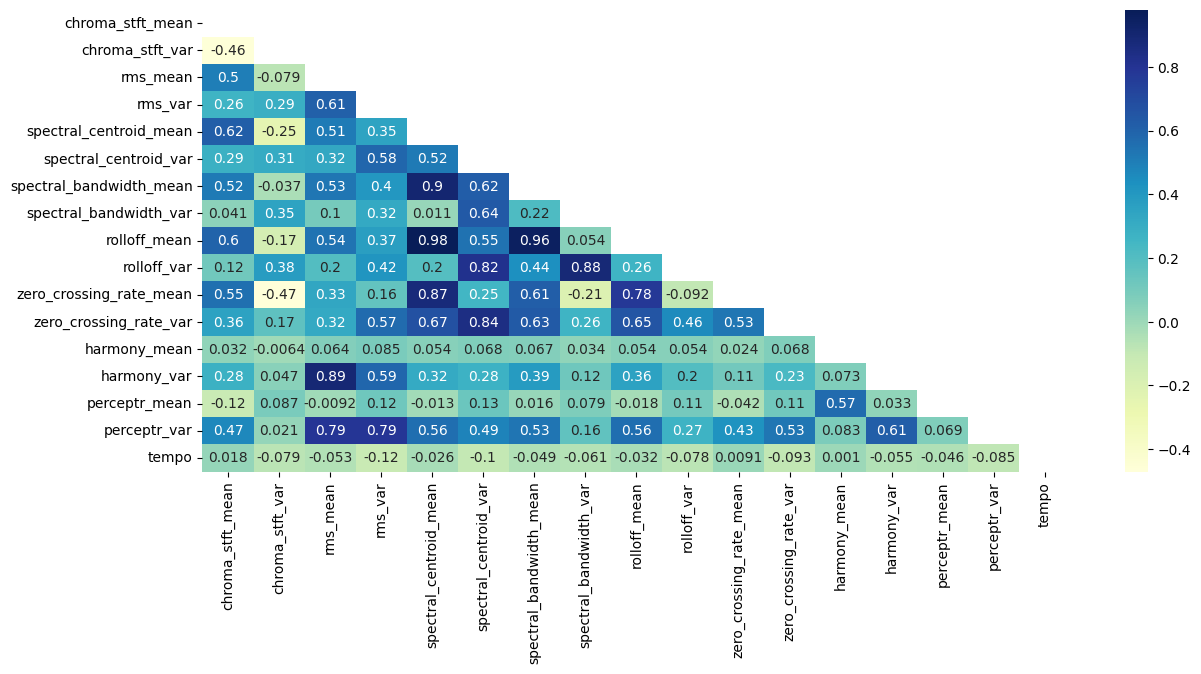

In [61]:
plt.figure(figsize=(14, 6)) 
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(df.corr(numeric_only=True)))
sns.heatmap(corr_matrix, cmap="YlGnBu", annot=True, mask=mask)
plt.show()

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('final_group', axis=1))
y = df['final_group']
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [96]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report

# Train a k-NN classifier
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print(f"Test Accuracy (k=6): {accuracy_score(y_test, y_pred):.2f}")


accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Weighted F1:", f1_weighted)
print("Macro F1:", f1_macro)
print(classification_report(y_test, y_pred))

Test Accuracy (k=6): 0.73
Accuracy: 0.7266666666666667
Weighted F1: 0.728182788208009
Macro F1: 0.7335000014697366
              precision    recall  f1-score   support

    Acoustic       0.85      0.74      0.79        90
    Electric       0.70      0.76      0.73        90
    Rhythmic       0.67      0.69      0.68       120

    accuracy                           0.73       300
   macro avg       0.74      0.73      0.73       300
weighted avg       0.73      0.73      0.73       300



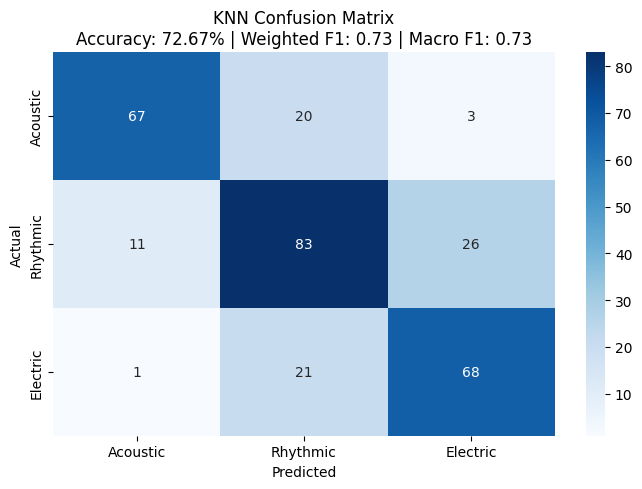

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ['Acoustic', 'Rhythmic', 'Electric']

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'KNN Confusion Matrix\nAccuracy: {accuracy:.2%} | Weighted F1: {f1_weighted:.2f} | Macro F1: {f1_macro:.2f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

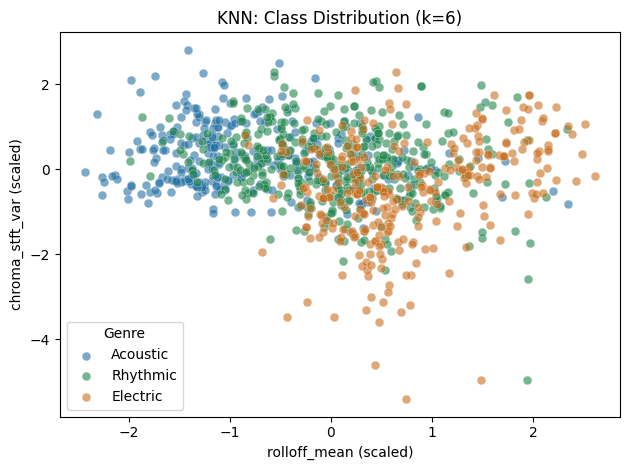

In [107]:
import matplotlib.pyplot as plt

feature_cols = [col for col in df.columns if col != 'final_group']
rolloff_idx = feature_cols.index('rolloff_mean')
centroid_idx = feature_cols.index('chroma_stft_var')

colors = {'Acoustic': '#2471a3', 'Rhythmic': '#1e8449', 'Electric': '#ca6f1e'}

for group, color in colors.items():
    mask = df['final_group'] == group
    plt.scatter(X_scaled[mask, rolloff_idx], 
                X_scaled[mask, centroid_idx],
                label=group, color=color, alpha=0.6, edgecolors='white', linewidths=0.3, s=40)

plt.xlabel('rolloff_mean (scaled)')
plt.ylabel('chroma_stft_var (scaled)')
plt.title('KNN: Class Distribution (k=6)')
plt.legend(title='Genre')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

rolloff_idx = feature_cols.index('rolloff_mean') #indexing/keeping track of original df to scaled df
chroma_idx = feature_cols.index('chroma_stft_var')
tempo_idx = feature_cols.index('tempo')

plot_df = pd.DataFrame({
    'rolloff_mean': X_scaled[:, rolloff_idx],
    'chroma_stft_var': X_scaled[:, chroma_idx],
    'tempo': X_scaled[:, tempo_idx],
    'final_group': df['final_group'].values
})

fig = px.scatter_3d(plot_df,
                    x='rolloff_mean',
                    y='chroma_stft_var',
                    z='tempo',
                    color='final_group',
                    opacity=0.7,
                    title='KNN: Class Distribution 3D (k=6)',
                    color_discrete_map={
                        'Acoustic': '#2471a3',
                        'Rhythmic': '#1e8449',
                        'Electric': '#ca6f1e'
                    },
                    labels={'final_group': 'Genre'})

fig.update_traces(marker=dict(size=6))
fig.update_layout(width=1000, height=800)
fig.show()